In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import json

In [2]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})


In [3]:
path = "../Results/Safetorch/GraphSAGE_noCRoss_sisampler_f1score/analyzed_validation_results.csv"

df = pd.read_csv(path)

In [4]:
# Or Load hyperparameters from manually set values
hidden_dim = 16
learning_rate = 0.1
epochs = 10
dropout = 0.1
batch_size = 64
#n_heads = 4
weight_decay = 0.01

In [5]:
# Filter the data based on specific hyperparameters
mask = (df['hidden_dim'] == hidden_dim) & (df['dropout'] == dropout) & \
        (df['epochs'] == epochs )  & \
        (df['learning_rate'] == learning_rate ) & \
        (df['batch_size'] == batch_size) &  (df['weight_decay'] == weight_decay) #& \
        #(df['num_heads'] == n_heads) # Comment / Uncomment for GAT / GCN

# Filter the DataFrame based on the mask
filtered_df = df[mask]

In [6]:
# Remove the columns hidden_dim, dropout, learning_rate, epochs, batch_size, weight_decay, num_heads
filtered_df = filtered_df.drop(columns=['hidden_dim', 'dropout', 'learning_rate', 'epochs', 'batch_size', 'weight_decay', 'num_heads'])

In [7]:
import pandas as pd

# Existing utility functions
KNOWN_COMPILERS = {'gcc', 'clang'}

OPT_TOKEN_MAP = {
    '0': 'O0', '1': 'O1', '2': 'O2', '3': 'O3',
    's': 'Os', 'fast': 'Ofast',
    'O0': 'O0', 'O1': 'O1', 'O2': 'O2', 'O3': 'O3',
    'Os': 'Os', 'Ofast': 'Ofast',
}

def parse_filename(fn: str):
    """
    Splits a filename into (program, optimization, compiler).
    """
    base = fn.replace('.pt', '')
    parts = base.split('_')
    settings_idx = None
    for i, tok in enumerate(parts[1:], start=1):
        if tok in KNOWN_COMPILERS or tok in OPT_TOKEN_MAP or tok.isdigit():
            settings_idx = i
            break

    if settings_idx is None:
        program = base
        settings = []
    else:
        program = '_'.join(parts[:settings_idx])
        settings = parts[settings_idx:]

    compiler = next((s for s in settings if s in KNOWN_COMPILERS), 'default')

    # Default to gcc if no compiler found
    if compiler == 'default':
        compiler = 'gcc'  

    opts = []
    for s in settings:
        if s in OPT_TOKEN_MAP:
            opts.append(OPT_TOKEN_MAP[s])
        elif s.isdigit() and s not in OPT_TOKEN_MAP:
            opts.append(s)
    optimization = '_'.join(opts) if opts else 'default'
    return program, optimization, compiler

# Core analysis functions
def compute_setting_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Count functions per (optimization, compiler).
    """
    return (
        df
        .groupby(['optimization', 'compiler'])
        .size()
        .reset_index(name='num_functions')
    )

def compute_unique_program_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Count distinct programs per (optimization, compiler).
    """
    return (
        df
        .groupby(['optimization', 'compiler'])['program']
        .nunique()
        .reset_index(name='unique_programs')
    )

def compute_setting_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge function-counts and program-counts into a single DataFrame.
    """
    counts = compute_setting_counts(df)
    uniques = compute_unique_program_counts(df)
    return pd.merge(counts, uniques, on=['optimization', 'compiler'])

def compute_distributions(df: pd.DataFrame) -> dict:
    """
    Returns counts per compiler and per optimization.
    """
    return {
        'compiler': df['compiler'].value_counts(),
        'optimization': df['optimization'].value_counts(),
    }

def compute_global_totals(df: pd.DataFrame) -> dict:
    """
    Returns total functions and distinct programs.
    """
    return {
        'total_functions': len(df),
        'total_programs': df['program'].nunique(),
    }

def compute_numeric_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Descriptive statistics for numeric columns.
    """
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        return pd.DataFrame()
    return df[numeric_cols].describe()

# New: Filtering and summary function
def summarize_program(df: pd.DataFrame, program_name: str = None) -> None:
    """
    Print a summary of the DataFrame, optionally filtered by program_name.

    Summary includes:
      - Number and list of distinct compilers
      - Number and list of distinct optimizations
      - Total functions per compiler
      - Total functions per optimization
      - Detailed per-setting stats (num functions & unique programs)
    """
    # Optionally filter by program
    if program_name:
        df = df[df['program'] == program_name]
        print(f"\n=== Summary for program: '{program_name}' ===")
    else:
        print("\n=== Summary for all programs ===")

    # Distinct compilers and optimizations
    compilers = sorted(df['compiler'].unique())
    opts = sorted(df['optimization'].unique())
    print(f"Distinct compilers ({len(compilers)}): {compilers}")
    print(f"Distinct optimizations ({len(opts)}): {opts}\n")

    # Totals per compiler and optimization
    comp_dist = df['compiler'].value_counts()
    opt_dist = df['optimization'].value_counts()
    print("Total functions per compiler:")
    print(comp_dist.to_string())
    print("\nTotal functions per optimization:")
    print(opt_dist.to_string())

    # Detailed setting stats
    stats = compute_setting_stats(df)
    print("\nDetailed (optimization, compiler) stats:")
    print(stats.sort_values('num_functions', ascending=False).to_string(index=False))


df = filtered_df.copy()
# Parse filenames and extract program, optimization, compiler
df['program'], df['optimization'], df['compiler'] = zip(*df['filename'].apply(parse_filename))
# Save to csv
# df.to_csv('../Results/GAT_grid2/df_results.csv', index=False)
df.head()


,filename,name,address,node_shape,edge_shape,true_label,prediction,parser_probability,dataset_len,program,optimization,compiler
386326,example_3_32.pt,sym.deregister_tm_clones,0x80492c0,"(5, 100)","(2, 5)",0,0,0.270489,653,example,O3_32,gcc
386327,example_3_32.pt,sym.register_tm_clones,0x8049300,"(5, 100)","(2, 5)",0,0,0.253482,653,example,O3_32,gcc
386328,example_3_32.pt,sym.__do_global_dtors_aux,0x8049340,"(5, 100)","(2, 4)",0,0,0.187454,653,example,O3_32,gcc
386329,example_3_32.pt,sym.frame_dummy,0x8049370,"(6, 100)","(2, 6)",0,0,0.373241,653,example,O3_32,gcc
386330,example_3_32.pt,sym.json_parse_string,0x8049430,"(30, 100)","(2, 44)",1,1,0.589929,653,example,O3_32,gcc


In [8]:
gb_functions = df.groupby(['name','program'],as_index=False).agg({'compiler':'count'})

In [9]:
sel_functions = gb_functions[gb_functions.compiler == 28].copy() 

In [10]:
sel_functions

,name,program,compiler
1,main,cjson,28
2,main,elf-parser,28
3,main,example,28
4,main,network_analyzer,28
5,main,packcc,28
...,...,...,...
365,sym.test_headers,picohttpparser,28
366,sym.test_request,picohttpparser,28
367,sym.test_response,picohttpparser,28
368,sym.unescape_string,packcc,28


In [11]:
sel_df = pd.merge(df,sel_functions[['name','program']],on=['name','program'])

In [12]:
sel_df.shape

(5040, 12)

In [13]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Example: assuming your DataFrame is named `df`
# df = pd.read_csv('your_file.csv')

# Prepare a list to collect results
results = []

# Group by optimization and compiler
grouped = sel_df.groupby(['optimization', 'compiler'])

# Iterate over each group and compute the metrics
for (opt, comp), group in grouped:
    y_true = group['true_label']
    y_pred = group['prediction']
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    count = len(group)
    
    results.append({
        'optimization': opt,
        'compiler': comp,
        'count':count,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display the results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Metrics per (optimization, compiler)", dataframe=results_df)

In [14]:
df_gcc = results_df[results_df.compiler=='gcc'].sort_values('recall',ascending=False)

In [15]:
df_gcc

,optimization,compiler,count,precision,recall,f1_score,accuracy
15,O3,gcc,180,0.347826,0.975610,0.512821,0.577778
19,Ofast,gcc,180,0.347826,0.975610,0.512821,0.577778
11,O2,gcc,180,0.342105,0.951220,0.503226,0.572222
17,O3_32,gcc,180,0.348214,0.951220,0.509804,0.583333
21,Ofast_32,gcc,180,0.351351,0.951220,0.513158,0.588889
23,Os,gcc,180,0.375000,0.951220,0.537931,0.627778
7,O1,gcc,180,0.422222,0.926829,0.580153,0.694444
9,O1_32,gcc,180,0.431818,0.926829,0.589147,0.705556
13,O2_32,gcc,180,0.348624,0.926829,0.506667,0.588889
25,Os_32,gcc,180,0.342342,0.926829,0.500000,0.577778


In [16]:
df_clang = results_df[results_df.compiler=='clang'].sort_values('recall',ascending=False)

In [17]:
df_clang

,optimization,compiler,count,precision,recall,f1_score,accuracy
6,O1,clang,180,0.362832,1.000000,0.532468,0.600000
10,O2,clang,180,0.362832,1.000000,0.532468,0.600000
14,O3,clang,180,0.359649,1.000000,0.529032,0.594444
18,Ofast,clang,180,0.359649,1.000000,0.529032,0.594444
22,Os,clang,180,0.372727,1.000000,0.543046,0.616667
8,O1_32,clang,180,0.360360,0.975610,0.526316,0.600000
12,O2_32,clang,180,0.370370,0.975610,0.536913,0.616667
16,O3_32,clang,180,0.363636,0.975610,0.529801,0.605556
20,Ofast_32,clang,180,0.363636,0.975610,0.529801,0.605556
24,Os_32,clang,180,0.392157,0.975610,0.559441,0.650000


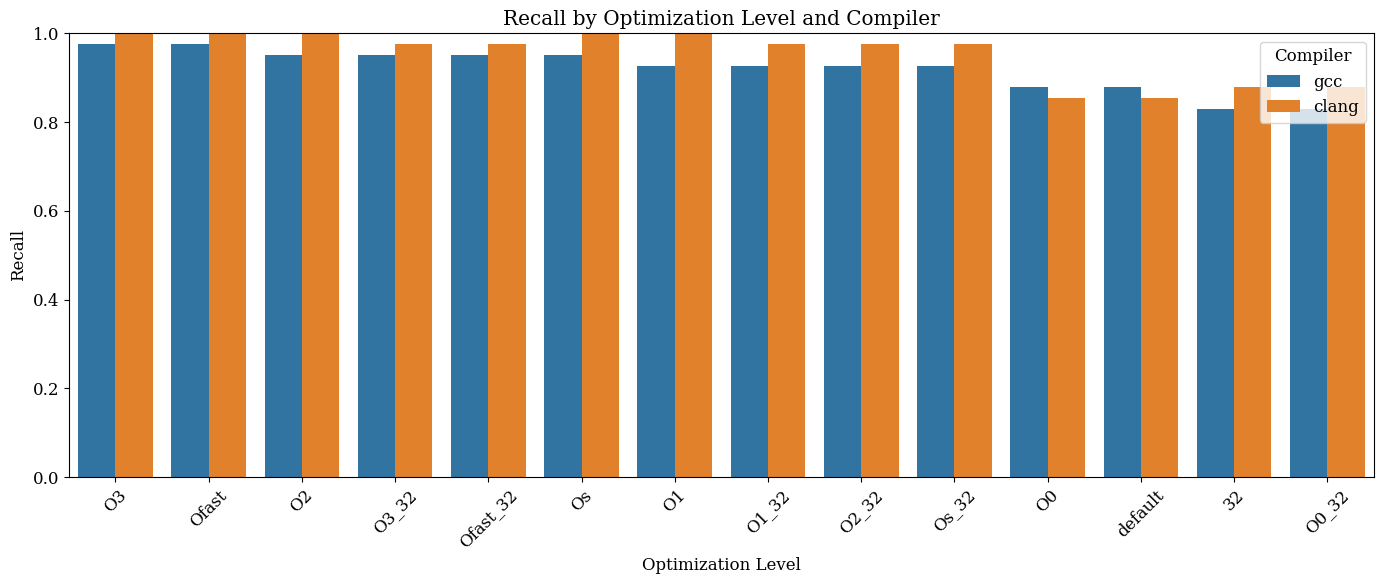

In [18]:

# Recreate the full DataFrame with optimization, recall, and compiler
# df_gcc = pd.DataFrame(gcc_data)
# df_clang = pd.DataFrame(clang_data)
df_all = pd.concat([df_gcc, df_clang], ignore_index=True)

# Set the plot size and style
plt.figure(figsize=(14, 6))
sns.barplot(data=df_all, x="optimization", y="recall", hue="compiler")

plt.xticks(rotation=45)
plt.xlabel("Optimization Level")
plt.ylabel("Recall")
plt.title("Recall by Optimization Level and Compiler")
plt.ylim(0, 1)
plt.legend(title="Compiler")
plt.tight_layout()
plt.savefig('full_bars.pdf')

In [20]:
df_all['architecture'] = df_all.optimization.apply(lambda x: 'x86-32' if '32' in x else 'x86-64' ) 

In [21]:
df_all[df_all.architecture == 'x86-64']['optimization'].unique()

array(['O3', 'Ofast', 'O2', 'Os', 'O1', 'O0', 'default'], dtype=object)

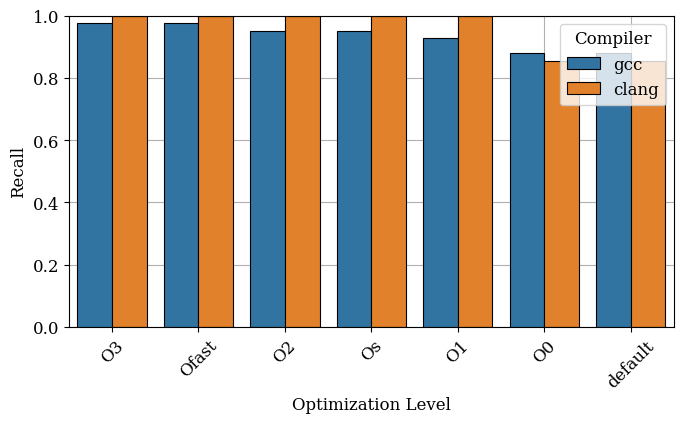

In [22]:
plt.figure(figsize=(7, 4.4)) 
ax = sns.barplot(data=df_all[df_all.architecture == 'x86-64'], x="optimization", y="recall", hue="compiler",edgecolor="black",   # black edge
    linewidth=0.8        # thin line; adjust as needed
                )
ax.set_axisbelow(True)
plt.xticks(rotation=45)
plt.xlabel("Optimization Level")
plt.ylabel("Recall")
# plt.title("Recall by Optimization Level and Compiler")
plt.ylim(0, 1)
plt.legend(title="Compiler")
plt.grid(which='both')

plt.tight_layout()
plt.savefig('x86-64-recall.pdf')
plt.show()

In [23]:
df_all[df_all.architecture == 'x86_32'].optimization.unique()

array([], dtype=object)

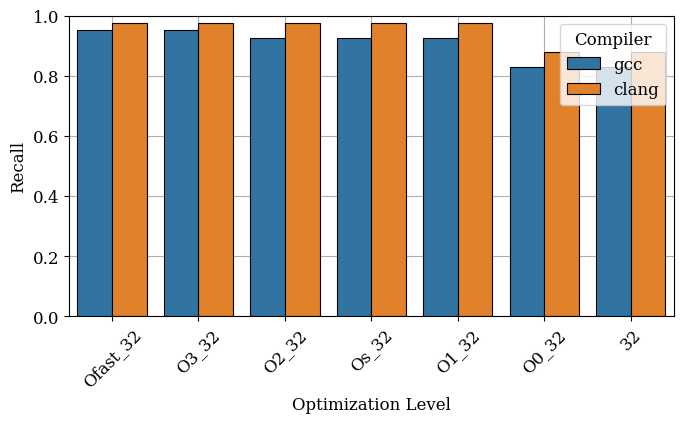

In [24]:
ax.set_axisbelow(False)
plt.figure(figsize=(7, 4.4)) 
ax = sns.barplot(data=df_all[df_all.architecture == 'x86-32'], x="optimization", y="recall",
            hue="compiler",order=['Ofast_32', 'O3_32', 'O2_32', 'Os_32', 'O1_32', 'O0_32', '32'],
            edgecolor="black",   # black edge
            linewidth=0.8        # thin line; adjust as needed
                )

ax.set_axisbelow(True)
plt.xticks(rotation=45)
plt.xlabel("Optimization Level")
plt.ylabel("Recall")
# plt.title("Recall by Optimization Level and Compiler")
plt.ylim(0, 1)
plt.grid(which='both')

plt.legend(title="Compiler")
plt.tight_layout()
plt.savefig('x86-32-recall.pdf')

In [25]:
df_all[(df_all.architecture == 'x86-32') & (df_all.compiler == 'gcc') ].recall.mean(),df_all[(df_all.architecture == 'x86-32') & (df_all.compiler == 'gcc') ].recall.std()

(0.9059233449477351, 0.05348933305305207)

In [26]:
df_all[(df_all.architecture == 'x86-64') & (df_all.compiler == 'gcc') ].recall.mean(),df_all[(df_all.architecture == 'x86-64') & (df_all.compiler == 'gcc') ].recall.std()

(0.9337979094076655, 0.041569175768114454)

In [27]:
df_all[(df_all.architecture == 'x86-32') & (df_all.compiler == 'clang') ].recall.mean(),df_all[(df_all.architecture == 'x86-32') & (df_all.compiler == 'clang') ].recall.std()

(0.9477351916376306, 0.04760488160724551)

In [28]:
df_all[(df_all.architecture == 'x86-64') & (df_all.compiler == 'clang') ].recall.mean(),df_all[(df_all.architecture == 'x86-64') & (df_all.compiler == 'clang') ].recall.std()

(0.9581881533101045, 0.07140732241086829)